In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme()

In [16]:
all_data = {
    "Jahr": [2011, 2011, 2012, 2016, 2017, 2019, 2020, 2020, 2021, 2021, 2021, 2021, 2021, 2022, 2022, 2022, 2023, 2023, 2023, 2023, 2023],
    "Modell": ["ERGO", "EliXR", "EliXR-TIME", "Valx", "ElilE", "Criteria2Query (C2Q)", "Clinical Trial Parser", "Ensemble Modell", "ERNI", "MIMO", "RoBERTa", "CT-BERT", "ecBERT", "PubMedBERT", "SciBERT", "C2Q 2.0", "ClinicalTrialBERT", "Expert System", "C2Q 3.0", "AutoCriteria", "LeafAI"],
    "Typ": ["Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser", "Regelbasierte Parser, ML", "Regelbasierte Parser, ML", "BERT", "ML, BERT", "BERT", "BERT", "BERT", "BERT", "BERT", "BERT", "Regelbasierte Parser, ML", "BERT", "GPT", "ML, GPT", "GPT", "BERT"],
    "Datensatz": ["Manueller Datensatz", "Manueller Datensatz", "Manueller Datensatz", "Manueller Datensatz", "ElilE", "C2Q Datensatz", "FRD", "Manueller Datensatz", "Manueller Datensatz", "Manueller Datensatz", "Chia, FRD", "FRD", "Chia", "EliIE, Covance, Chia", "LCT", "COVIC", "PROTECTOR1", "Manueller Datensatz", "Manueller Datensatz", "Manueller Datensatz", "LLF"]
}


data = {
    "Jahr": [2020, 2021, 2021, 2022, 2022, 2022],
    "Modell": ["Clinical Trial Parser", "RoBERTa", "CT-BERT", "PubMedBERT", "SciBERT", "C2Q 2.0"],
    "Typ": ["Regelbasierte Parser, ML", "BERT", "BERT", "BERT", "BERT", "Regelbasierte Parser, ML"],
    "Datensatz": ["FRD", "Chia, FRD", "FRD", "EliIE, Covance, Chia", "LCT", "COVIC"]
}

In [17]:
farben = {"Regelbasierte Parser": "blue", "ML": "green", "BERT": "orange", "GPT": "purple"}
markierungen = {
    "Manueller Datensatz": "MAN",
    "ElilE": "ElilE",
    "C2Q Datensatz": "C2Q Datensatz",
    "FRD": "FRD",
    "Chia": "Chia",
    "LCT Corpus": "LCT",
    "COVIC": "COVIC",
    "PROTECTOR1": "P1",
    "LLF Corpus": "LLF",
}
verfügbare_datasets = ["Chia", "FRD", "LCT", "LLF"]

In [18]:
df = pd.DataFrame(data)

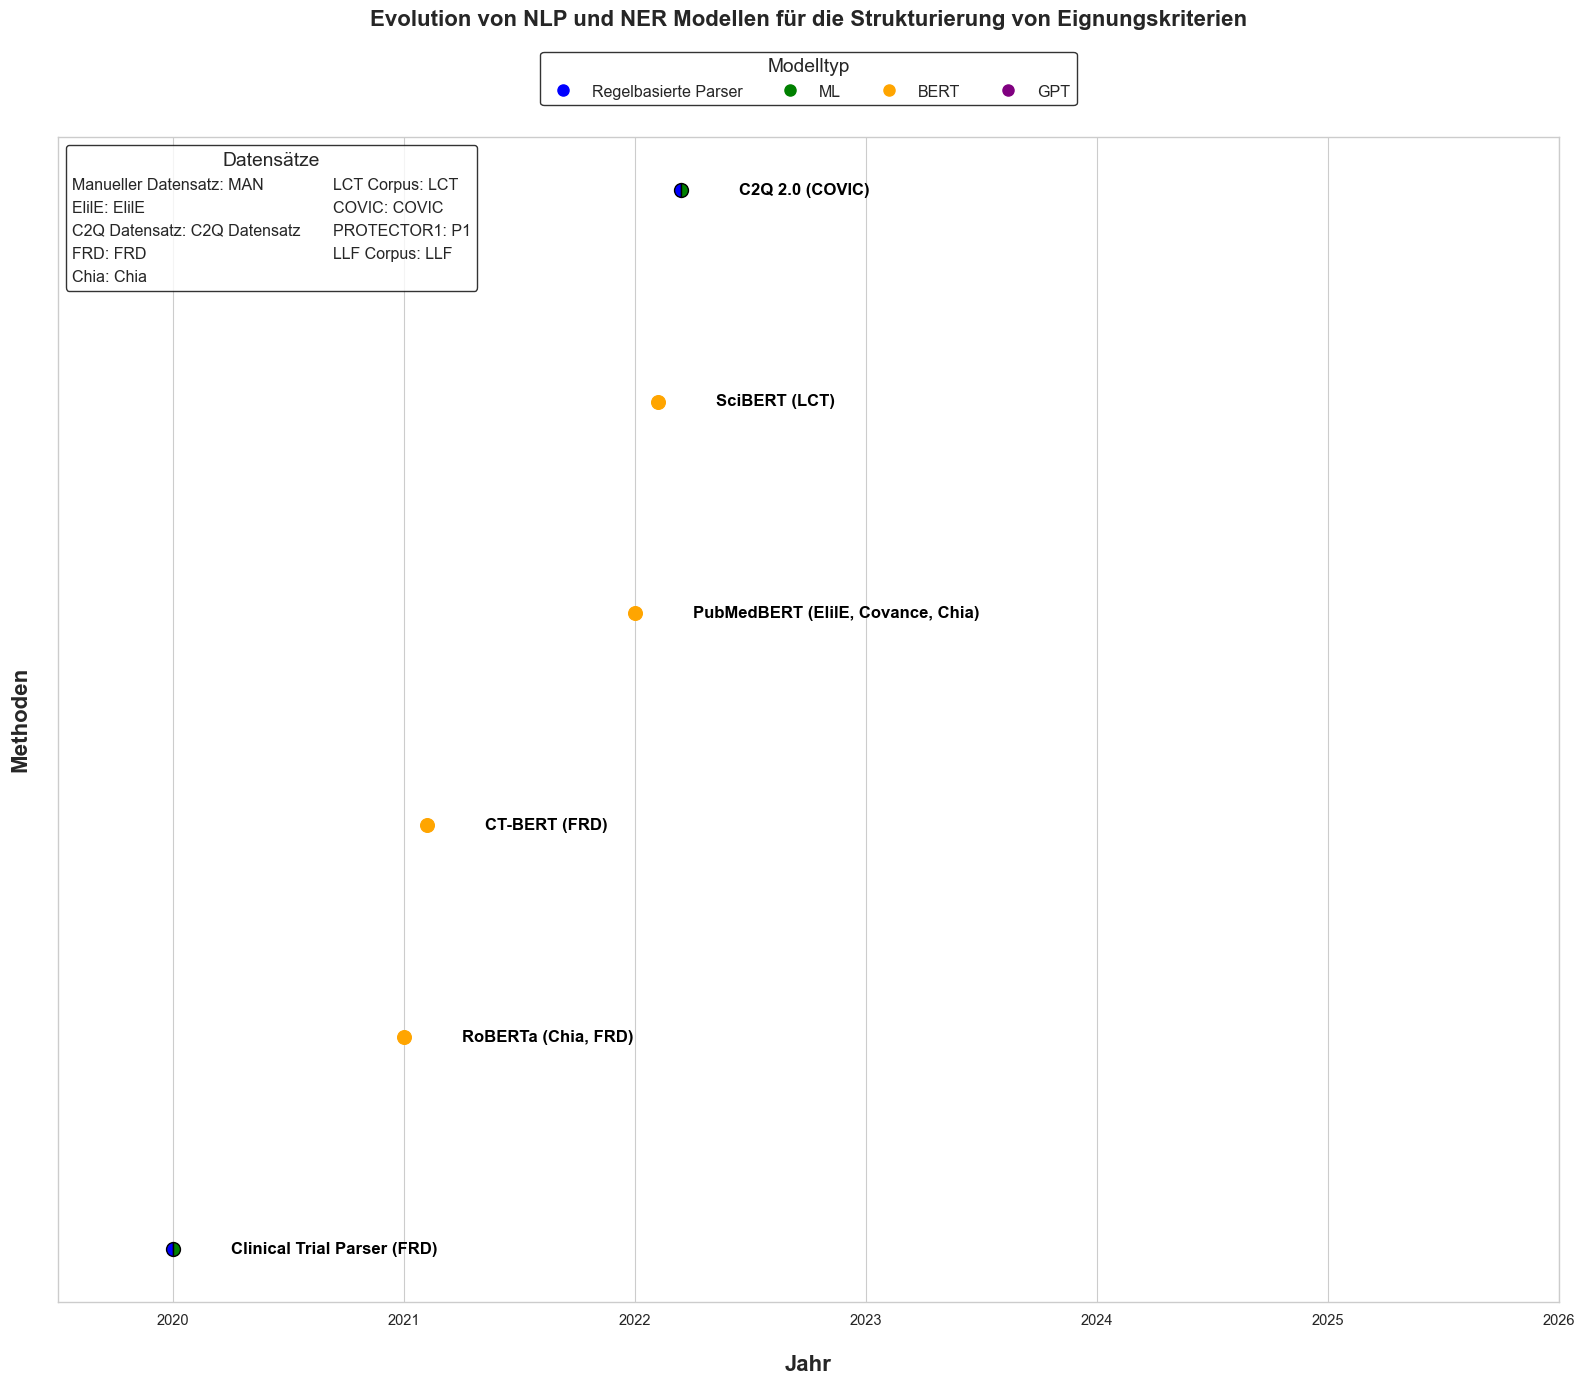

In [19]:

# Seaborn-Stil aktivieren
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

fig, ax = plt.subplots(figsize=(16, 14))

verschiebungen = df.groupby('Jahr').cumcount() * 0.1

for (index, row), verschiebung in zip(df.iterrows(), verschiebungen):
    x_wert = row["Jahr"] + verschiebung
    dataset_list = row["Datensatz"].split(", ")
    dataset_text = ", ".join([f"{markierungen.get(d.strip(), d.strip())}" for d in dataset_list])
    ax.text(x_wert + 0.25, index, f"{row['Modell']} ({dataset_text})",
            verticalalignment='center', horizontalalignment='left',
            fontsize=12, color='black', weight='bold')
    typ_details = row["Typ"].split(", ")
    if len(typ_details) > 1:
        ax.plot(x_wert, index, marker='o', markersize=10, markerfacecolor=farben[typ_details[0]],
                markerfacecoloralt=farben[typ_details[1]], markeredgewidth=1, markeredgecolor='black',
                fillstyle='left', linestyle='None')
    else:
        ax.scatter(x_wert, index, color=farben.get(row["Typ"], "white"), marker='o', s=100)

ax.set_xlabel("Jahr", fontsize=16, weight='bold', labelpad=20)
ax.set_ylabel("Methoden", fontsize=16, weight='bold', labelpad=20)

ax.set_yticks([])
ax.set_title("Evolution von NLP und NER Modellen für die Strukturierung von Eignungskriterien",
             fontsize=16, pad=80, weight='bold')

# Verbessertes Grid
ax.grid(True)

ax.set_xlim(min(df['Jahr'])-0.5, 2026)
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.5))

typ_legend = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', label=typ, markersize=8)
              for typ, color in farben.items()]

leg1 = ax.legend(handles=typ_legend, title="Modelltyp", loc='upper center',
                 bbox_to_anchor=(0.5, 1.08), ncol=5, fontsize='medium', title_fontsize='large')

dataset_legend = [plt.Line2D([0], [0], label=f"{key}: {value}", linestyle='')
                  for key, value in markierungen.items()]
ax.add_artist(leg1)
leg2 = ax.legend(handles=dataset_legend, title="Datensätze", loc='upper left',
                 bbox_to_anchor=(0.0, 1.0), ncol=2, fontsize='medium', title_fontsize='large',
                 handlelength=0, handletextpad=0)

for legend in [leg1, leg2]:
    frame = legend.get_frame()
    frame.set_edgecolor('black')
    frame.set_linewidth(1)

plt.tight_layout()
plt.savefig("./pics/evolution_modelle.png", bbox_inches='tight')
#plt.savefig("./pics/evolution_modelle.svg", format='svg', bbox_inches='tight')
plt.show()

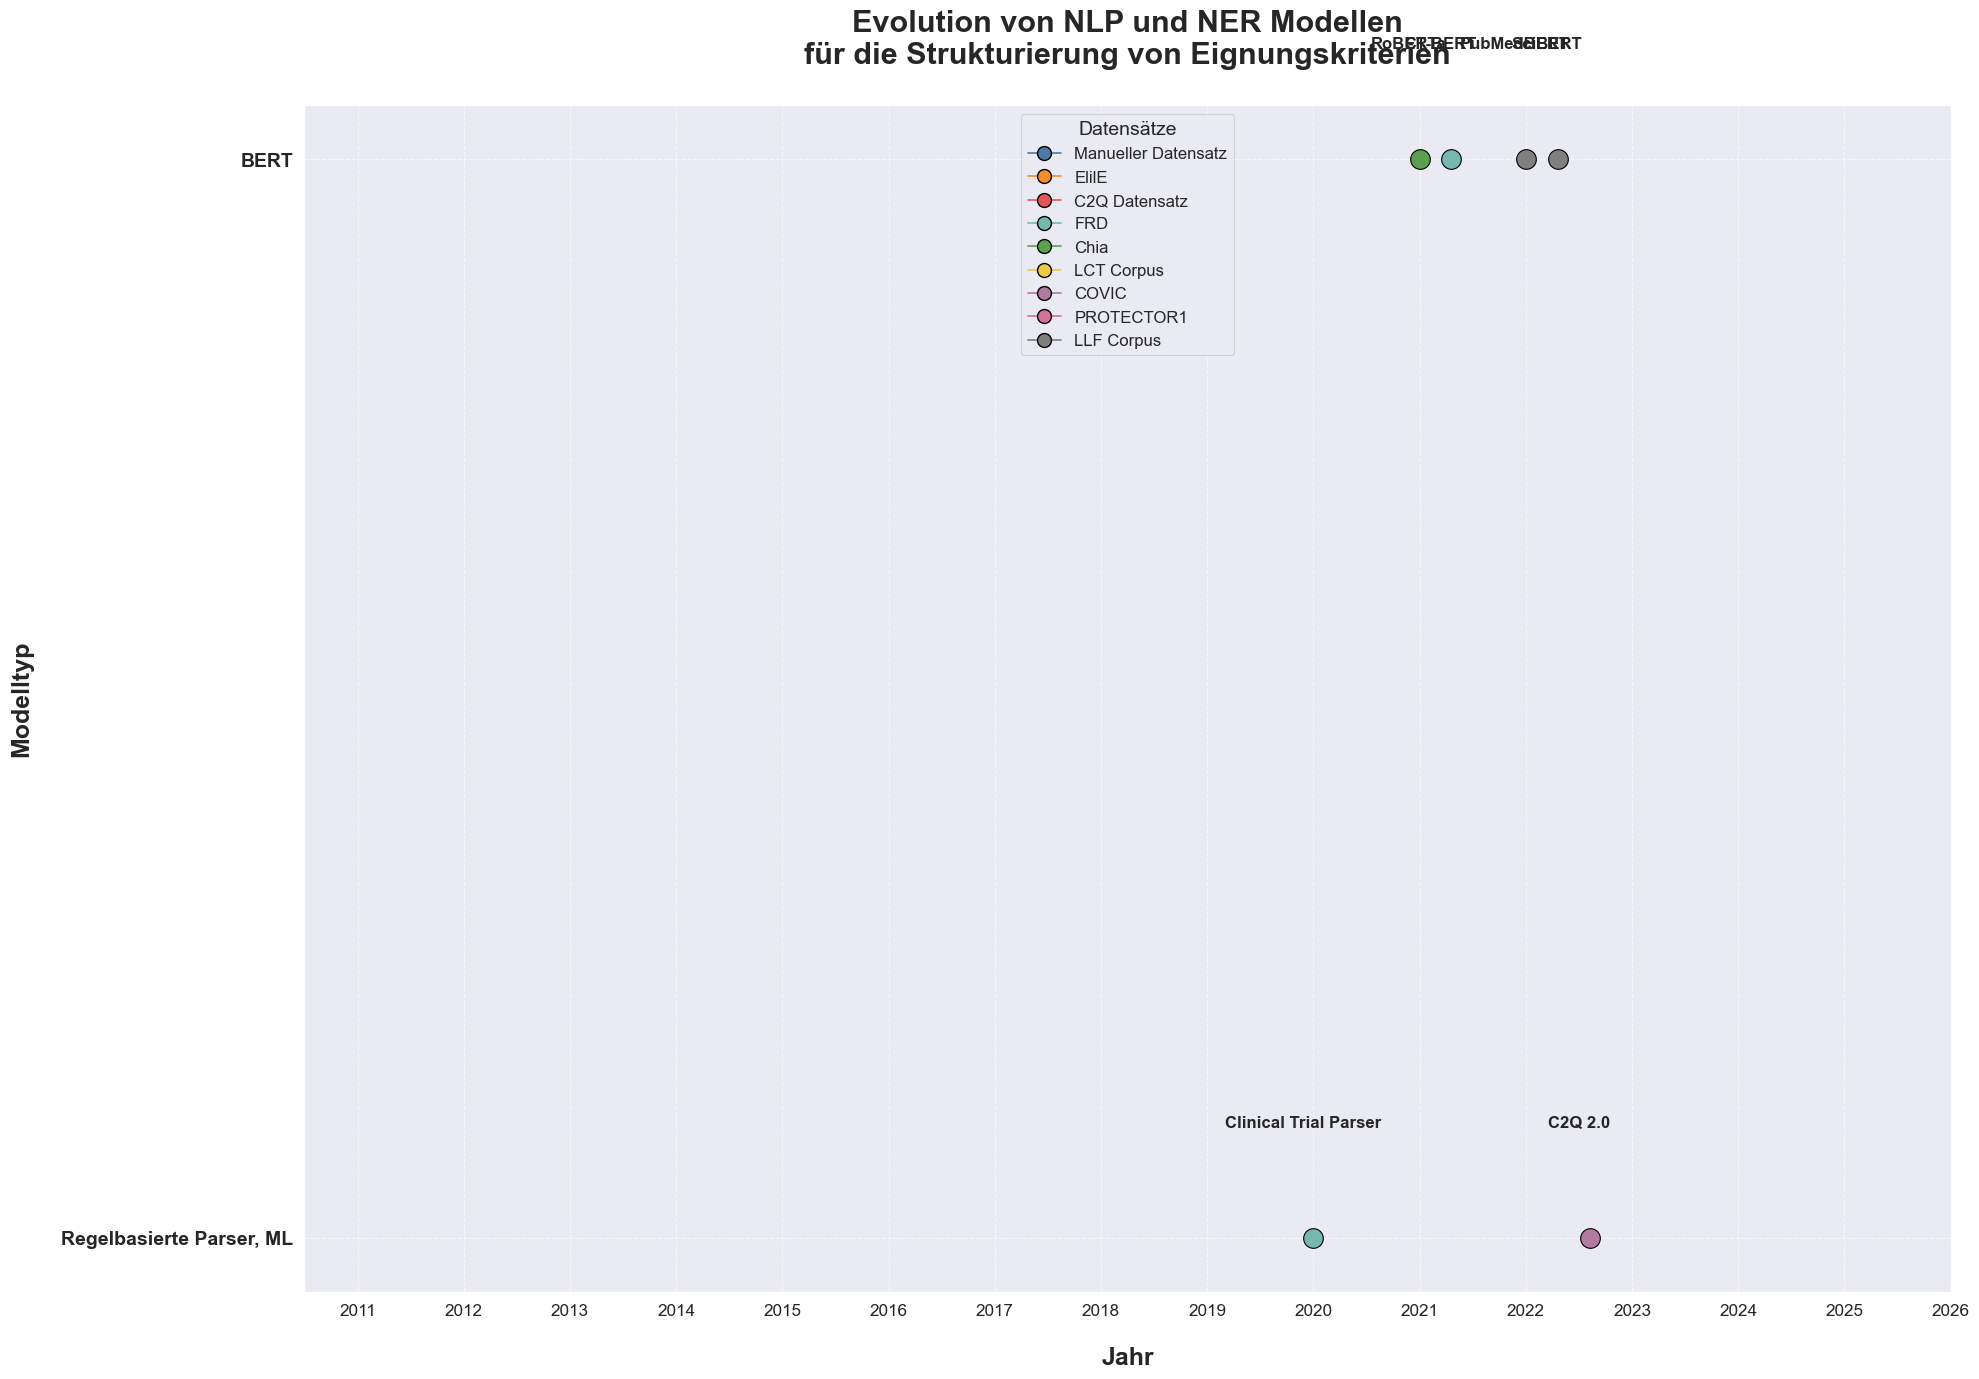

In [20]:
# Daten in DataFrame umwandeln
df = pd.DataFrame(data)

# Seaborn-Stil aktivieren
sns.set_style("darkgrid")
sns.set_context("paper", font_scale=1.4)

# Farbpalette für Datensätze definieren
farben = {
    "Manueller Datensatz": "#4E79A7",
    "ElilE": "#F28E2B",
    "C2Q Datensatz": "#E15759",
    "FRD": "#76B7B2",
    "Chia": "#59A14F",
    "LCT Corpus": "#EDC948",
    "COVIC": "#B07AA1",
    "PROTECTOR1": "#D37295",
    "LLF Corpus": "#7F7F7F"
}

# Marker für alle Datenpunkte einheitlich
marker = 'o'

fig, ax = plt.subplots(figsize=(20, 14))

# Erstellen Sie eine numerische Zuordnung für die Y-Achse
unique_types = df['Typ'].unique()
type_to_num = {typ: i for i, typ in enumerate(unique_types)}

verschiebungen = df.groupby('Jahr').cumcount() * 0.3

for (index, row), verschiebung in zip(df.iterrows(), verschiebungen):
    x_wert = row["Jahr"] + verschiebung
    y_wert = type_to_num[row['Typ']]
    dataset_list = row["Datensatz"].split(", ")

    color = farben.get(dataset_list[0], 'gray')

    ax.scatter(x_wert, y_wert, color=color, marker=marker, s=200, edgecolor='black')

    # Text über den Punkt setzen
    ax.text(x_wert-0.1, y_wert + 0.1, row['Modell'],
            verticalalignment='bottom', horizontalalignment='center',
            fontsize=12, fontweight='bold')

ax.set_xlabel("Jahr", fontsize=18, fontweight='bold', labelpad=20)
ax.set_ylabel("Modelltyp", fontsize=18, fontweight='bold', labelpad=20)

ax.set_title("Evolution von NLP und NER Modellen\nfür die Strukturierung von Eignungskriterien",
             fontsize=22, fontweight='bold', pad=30)

ax.grid(True, linestyle='--', alpha=0.7)
ax.set_xlim(2010.5, 2026)
ax.xaxis.set_major_locator(plt.MultipleLocator(1))

# Y-Achse Beschriftungen anpassen
plt.yticks(range(len(unique_types)), unique_types, fontsize=14, fontweight='bold')

# Legende für Datensätze
legend_elements_dataset = [plt.Line2D([0], [0], marker=marker, color=color, label=key, markersize=10, markeredgecolor='black')
                           for key, color in farben.items()]
ax.legend(handles=legend_elements_dataset, title="Datensätze", loc='upper center', fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.savefig("./pics/evolution_modelle_improved.png", bbox_inches='tight', dpi=300)
plt.show()

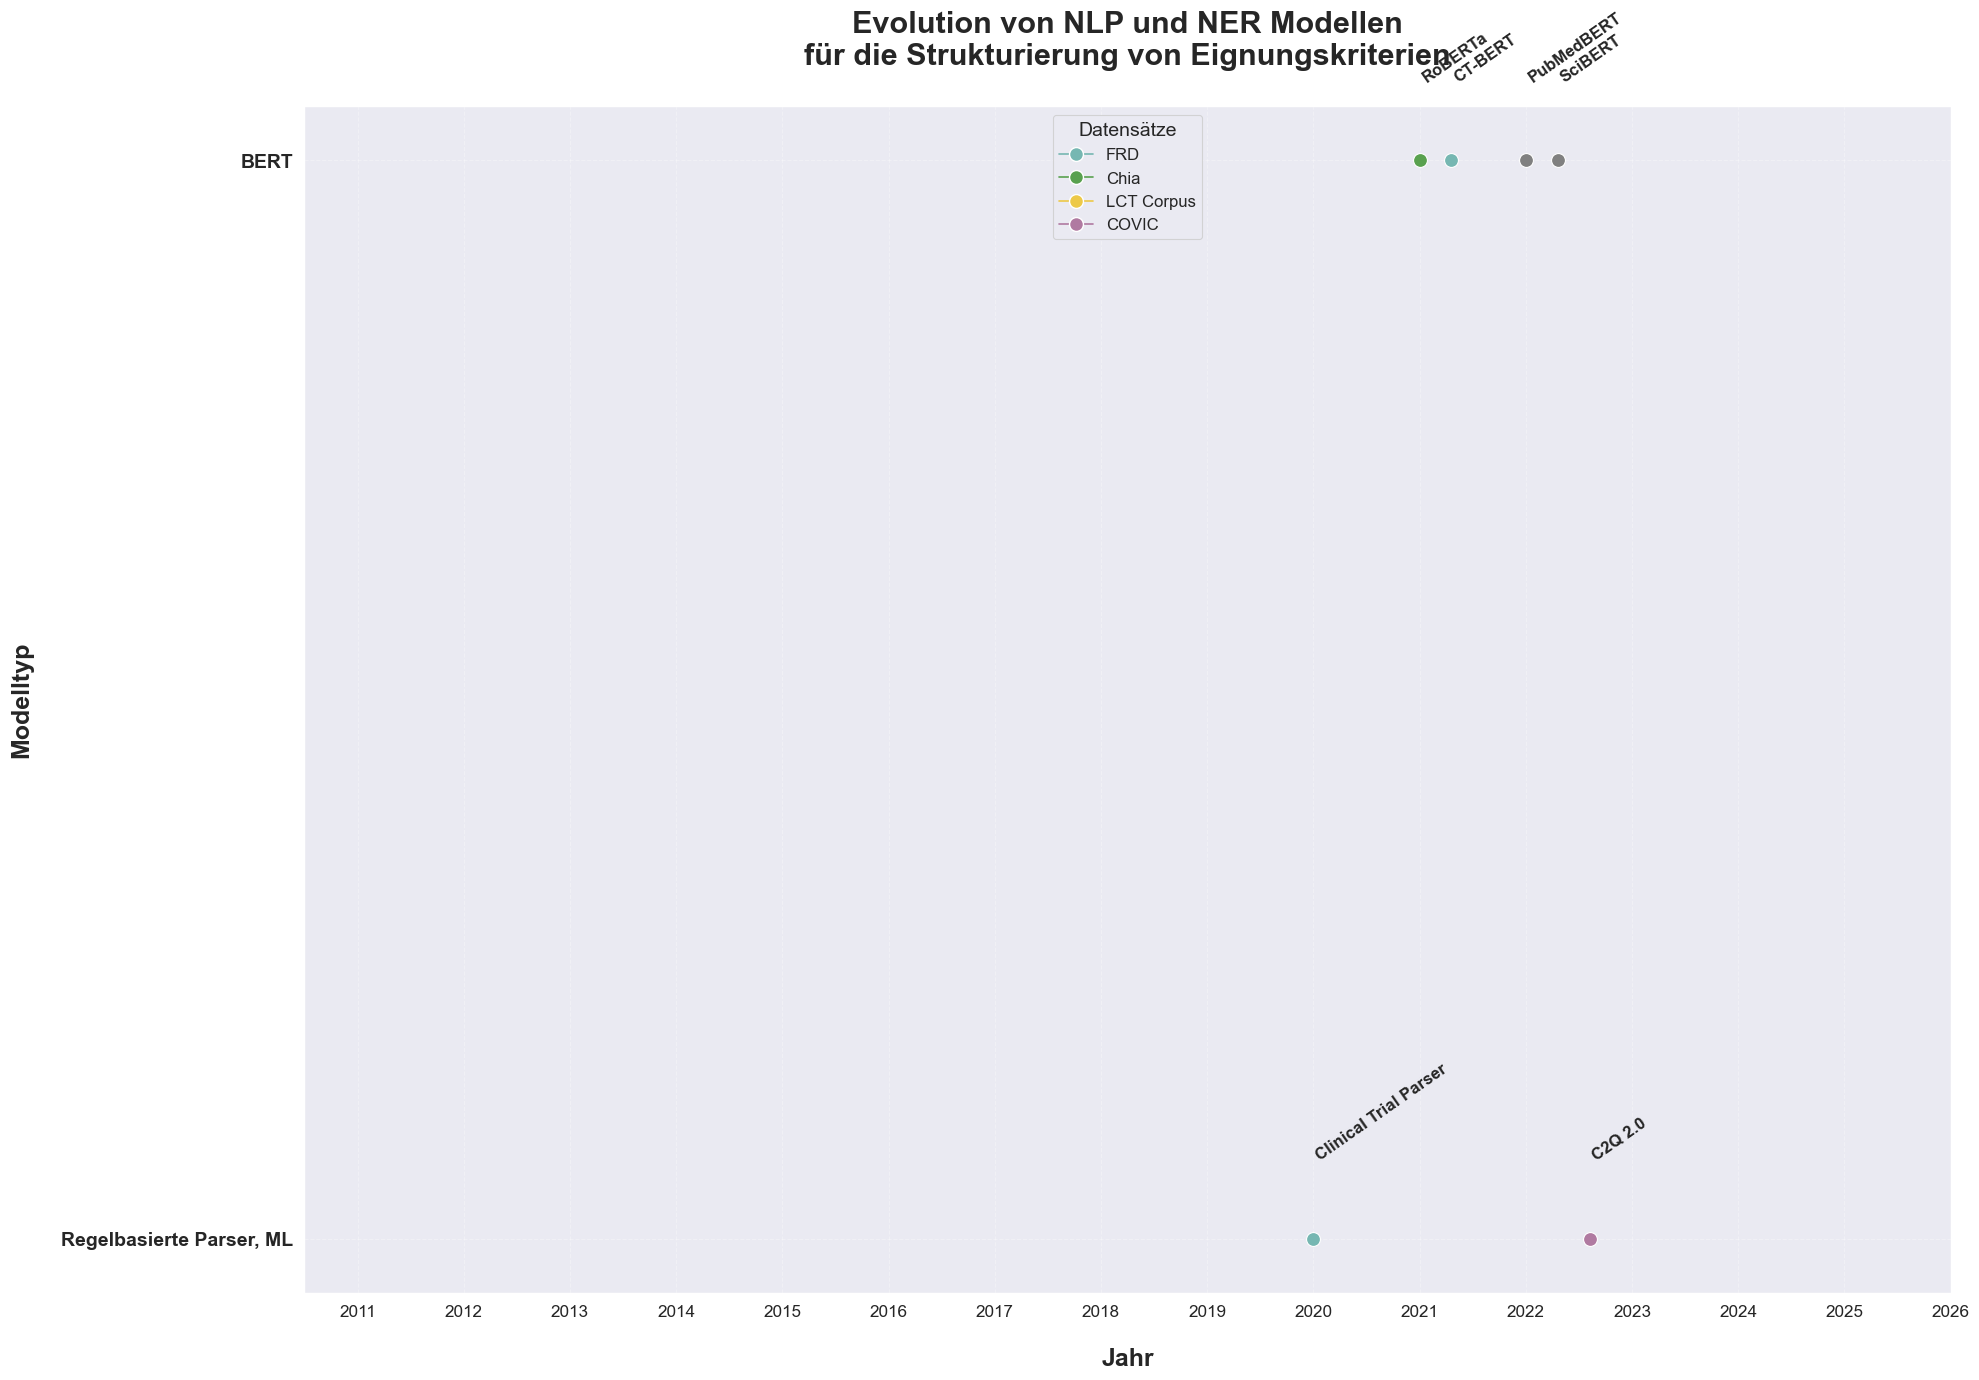

In [22]:

# Daten in DataFrame umwandeln
df = pd.DataFrame(data)
df = df[df['Typ'] != "ML, BERT"]
# Seaborn-Stil aktivieren

sns.set_context("paper", font_scale=1.4)

# Farbpalette für Datensätze definieren
farben = {
    "FRD": "#76B7B2",
    "Chia": "#59A14F",
    "LCT Corpus": "#EDC948",
    "COVIC": "#B07AA1",
}

marker = 'o'

fig, ax = plt.subplots(figsize=(20, 14))

unique_types = df['Typ'].unique()
type_to_num = {typ: i for i, typ in enumerate(unique_types)}

verschiebungen = df.groupby('Jahr').cumcount() * 0.3

for (index, row), verschiebung in zip(df.iterrows(), verschiebungen):
    x_wert = row["Jahr"] + verschiebung
    y_wert = type_to_num[row['Typ']]
    dataset_list = row["Datensatz"].split(", ")

    color = farben.get(dataset_list[0], 'gray')

    ax.scatter(x_wert, y_wert, color=color, marker=marker, s=100, edgecolor='white')

    ax.text(x_wert, y_wert + 0.07, row['Modell'],
            verticalalignment='bottom', horizontalalignment='left',
            fontsize=12, fontweight='bold', rotation=35)

ax.set_xlabel("Jahr", fontsize=18, fontweight='bold', labelpad=20)
ax.set_ylabel("Modelltyp", fontsize=18, fontweight='bold', labelpad=20)

ax.set_title("Evolution von NLP und NER Modellen\nfür die Strukturierung von Eignungskriterien",
             fontsize=22, fontweight='bold', pad=30)

ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlim(2010.5, 2026)
ax.xaxis.set_major_locator(plt.MultipleLocator(1))

plt.yticks(range(len(unique_types)), unique_types, fontsize=14, fontweight='bold')

legend_elements_dataset = [plt.Line2D([0], [0], marker=marker, color=color, label=key, markersize=10, markeredgecolor='white')
                           for key, color in farben.items()]
ax.legend(handles=legend_elements_dataset, title="Datensätze", loc='upper center', fontsize=12, title_fontsize=14)

plt.tight_layout()
plt.savefig("pics/evolution_modelle.png", bbox_inches='tight')
plt.show()